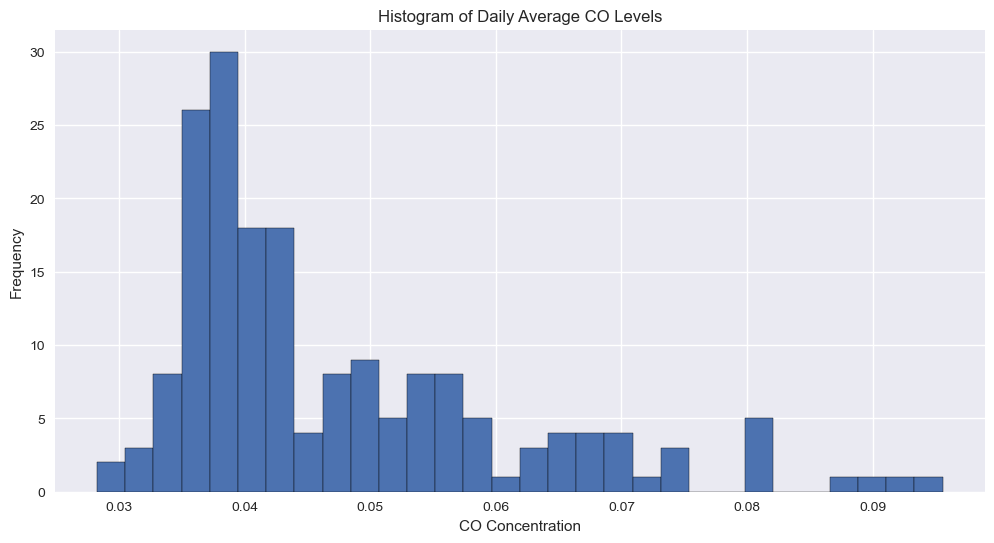

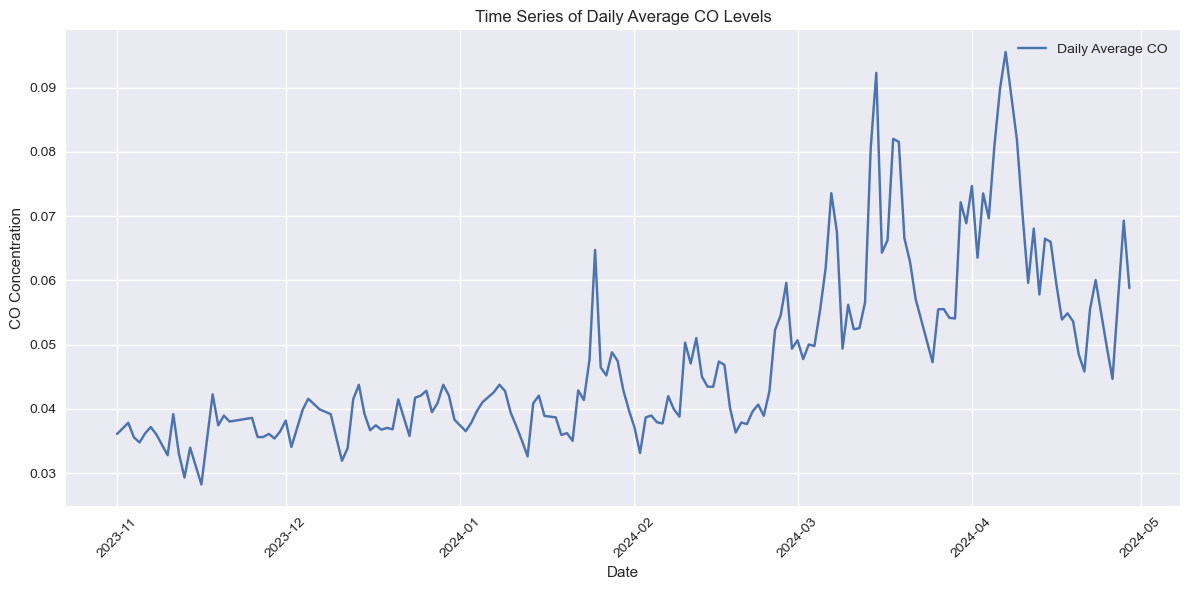

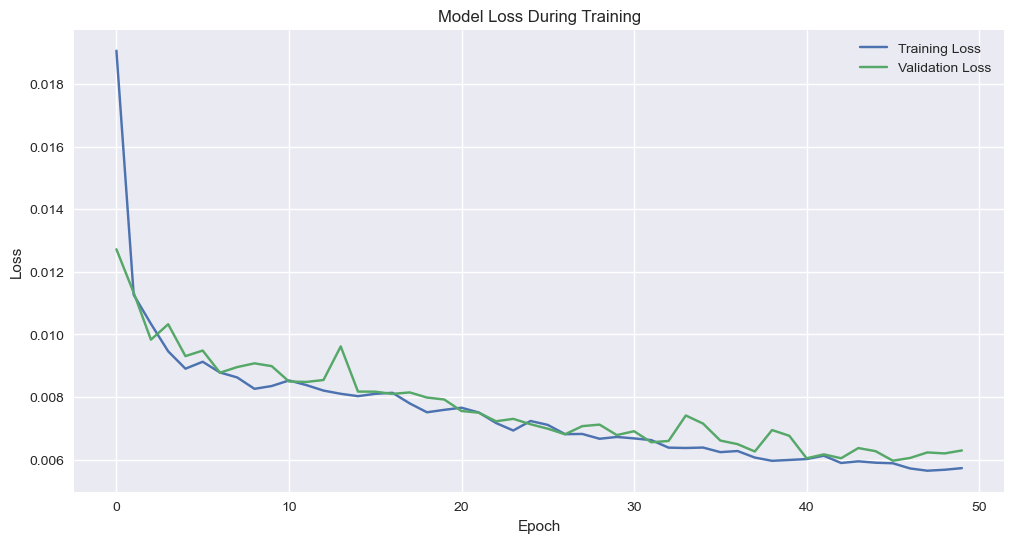

33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
RMSE: 0.0059
MAE: 0.0042
R²: 0.8323


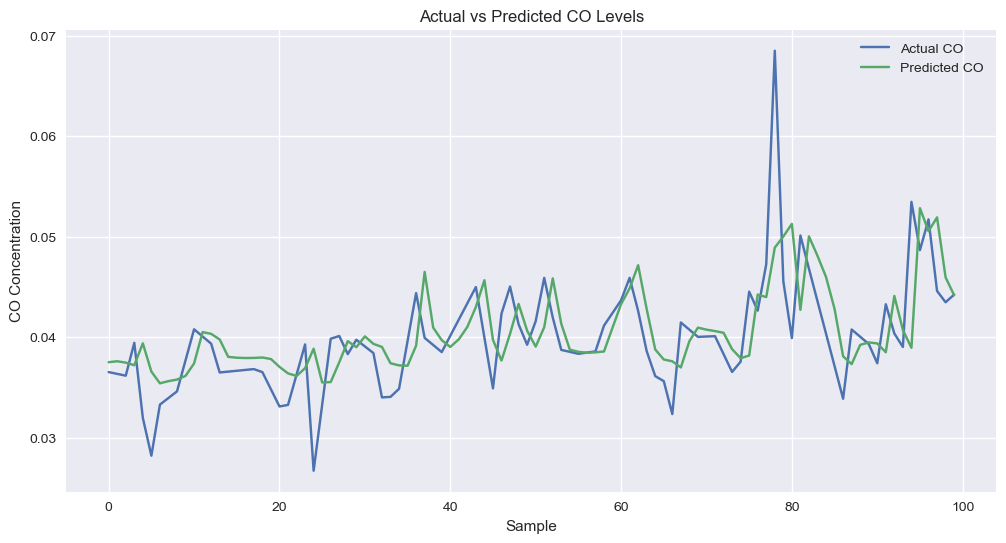

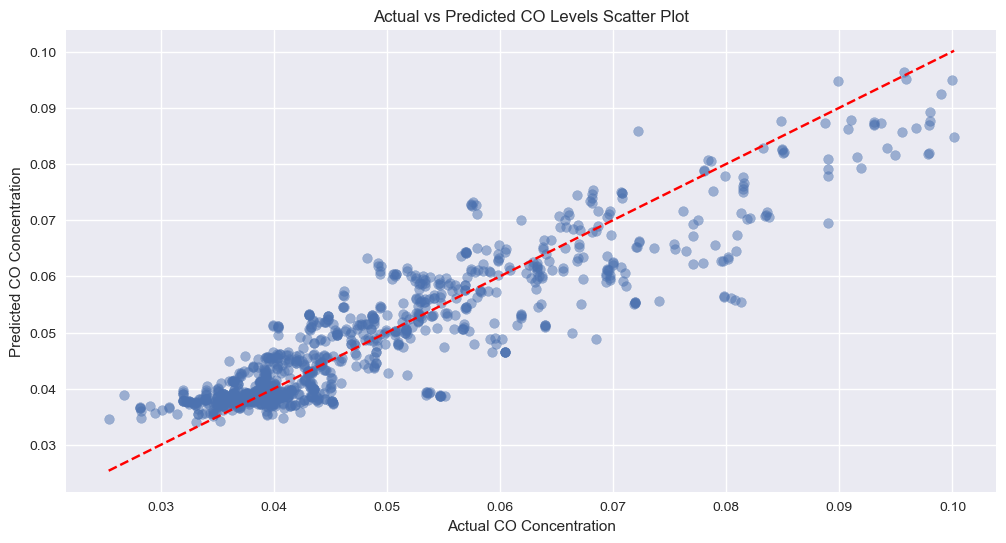

In [16]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import save_model, load_model
from tensorflow.keras.losses import MeanSquaredError
import io
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('CO_hex30_urban.csv') 

# Ensure 'date' column exists
if 'date' not in df.columns:
    raise KeyError("The 'date' column is missing from the input data")

# Converting date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Sorting data by sensor ID and date
df = df.sort_values(['id', 'date'])

# Handling missing values with time-based interpolation for each sensor
df['CO'] = df['CO'].replace('NA', np.nan)

# Fixed interpolation: set index to date for each group and interpolate
def interpolate_sensor(group):
    if 'date' not in group.columns:
        raise KeyError("The 'date' column is missing in the sensor group")
    group = group.set_index('date')
    group['CO'] = group['CO'].interpolate(method='time')
    group = group.reset_index()  # Ensure 'date' is returned as a column
    return group

# Apply interpolation while preserving DataFrame structure
df = df.groupby('id', group_keys=False).apply(interpolate_sensor)

# Verify 'date' column exists after interpolation
if 'date' not in df.columns:
    raise KeyError("The 'date' column is missing after interpolation")

# Drop any remaining NaN values (e.g., at the beginning)
df = df.dropna(subset=['CO'])

# Calculating daily average CO levels
daily_avg = df.groupby('date')['CO'].mean().reset_index()

plt.style.use('seaborn-v0_8')
# Plotting histogram of daily CO values
plt.figure(figsize=(12, 6))
plt.hist(daily_avg['CO'], bins=30, edgecolor='black')
plt.title('Histogram of Daily Average CO Levels')
plt.xlabel('CO Concentration')
plt.ylabel('Frequency')
plt.show()

# show time series of daily average CO levels
plt.figure(figsize=(12, 6))
plt.plot(daily_avg['date'], daily_avg['CO'], label='Daily Average CO')
plt.title('Time Series of Daily Average CO Levels') 
plt.xlabel('Date')
plt.ylabel('CO Concentration')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Preparing data for LSTM
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length])
        y.append(data[i + seq_length])
    return np.array(X), np.array(y)

# Scaling data
scaler = MinMaxScaler()
df['CO_scaled'] = scaler.fit_transform(df[['CO']])

# Creating sequences for each sensor
seq_length = 7  # Using 7 days as sequence length
X, y = [], []
for sensor_id in df['id'].unique():
    sensor_data = df[df['id'] == sensor_id]['CO_scaled'].values
    if len(sensor_data) >= seq_length + 1:
        X_sensor, y_sensor = create_sequences(sensor_data, seq_length)
        X.append(X_sensor)
        y.append(y_sensor)

if len(X) == 0:
    raise ValueError("Not enough data for sequences after interpolation")

X = np.concatenate(X, axis=0)
y = np.concatenate(y, axis=0)

# Splitting data into training and testing sets
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Building the LSTM model
model = Sequential([
    Bidirectional(LSTM(50, activation='relu', input_shape=(seq_length, 1), return_sequences=True)),
    Dropout(0.2),
    Bidirectional(LSTM(50, activation='relu')),
    Dropout(0.2),
    Dense(1)
])

model.compile(optimizer='adam', loss=MeanSquaredError())

# Setting up callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)

# Reshaping data for LSTM [samples, time steps, features]
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Training the model
history = model.fit(
    X_train, y_train, 
    epochs=50, 
    batch_size=32, 
    validation_data=(X_test, y_test),
    callbacks=[early_stopping, reduce_lr], 
    verbose=0,
)

# Plotting training history
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# Evaluating the model
y_pred = model.predict(X_test)
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))
y_pred_inv = scaler.inverse_transform(y_pred)

# Calculating performance metrics
rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'R²: {r2:.4f}')

# Plotting actual vs predicted values
plt.figure(figsize=(12, 6))
plt.plot(y_test_inv[:100], label='Actual CO')
plt.plot(y_pred_inv[:100], label='Predicted CO')
plt.title('Actual vs Predicted CO Levels')
plt.xlabel('Sample')
plt.ylabel('CO Concentration')
plt.legend()
plt.show()


# add scatter plot of actual vs predicted
plt.figure(figsize=(12, 6))
plt.scatter(y_test_inv, y_pred_inv, alpha=0.5)
plt.title('Actual vs Predicted CO Levels Scatter Plot')
plt.xlabel('Actual CO Concentration')
plt.ylabel('Predicted CO Concentration')
plt.plot([y_test_inv.min(), y_test_inv.max()], [y_test_inv.min(), y_test_inv.max()], 'r--')  # Diagonal line
plt.show()  


7-Day CO Forecast:
        date  hexagon_1  hexagon_2  hexagon_3  hexagon_4  hexagon_5  \
0 2024-04-30   0.065153   0.062916   0.063844   0.066036   0.062964   
1 2024-05-01   0.063784   0.062284   0.062578   0.065393   0.062488   
2 2024-05-02   0.064066   0.062784   0.062899   0.065728   0.063025   
3 2024-05-03   0.066819   0.065116   0.065272   0.068805   0.065568   
4 2024-05-04   0.073063   0.070641   0.070868   0.075267   0.071422   
5 2024-05-05   0.083512   0.079884   0.080093   0.086078   0.081094   
6 2024-05-06   0.083928   0.081178   0.082912   0.084742   0.080848   

   hexagon_6  hexagon_7  hexagon_8  hexagon_9  ...  hexagon_21  hexagon_22  \
0   0.062812   0.063295   0.065540   0.066065  ...    0.065239    0.065024   
1   0.062264   0.062372   0.063938   0.065716  ...    0.065155    0.064146   
2   0.062771   0.062816   0.064142   0.066011  ...    0.065140    0.064110   
3   0.065124   0.065182   0.066909   0.069050  ...    0.067709    0.066600   
4   0.070664   0.0707

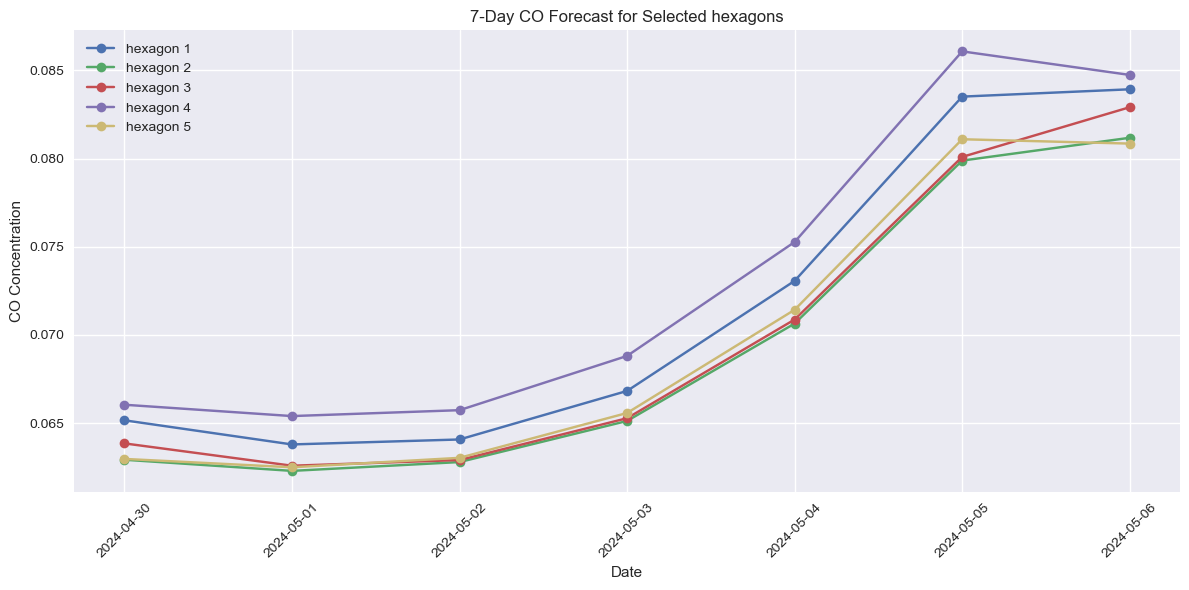


Sample 7-Day Forecast for hexagon 1:
        Date  hexagon_1_Forecast
0 2024-04-30            0.065153
1 2024-05-01            0.063784
2 2024-05-02            0.064066
3 2024-05-03            0.066819
4 2024-05-04            0.073063
5 2024-05-05            0.083512
6 2024-05-06            0.083928


In [19]:

# Forecasting the next 7 days
last_date = df['date'].max()
forecast_dates = [last_date + timedelta(days=i) for i in range(1, 8)]
forecasts = []

# Using the last sequence from each hexagon for forecasting
for hexagon_id in df['id'].unique():
    hexagon_data = df[df['id'] == hexagon_id]['CO_scaled'].values[-seq_length:]
    if len(hexagon_data) < seq_length:
        # Pad with last value if not enough data
        pad_length = seq_length - len(hexagon_data)
        padded = np.full(pad_length, hexagon_data[-1] if len(hexagon_data) > 0 else 0)
        hexagon_data = np.concatenate((padded, hexagon_data))
    current_sequence = hexagon_data[-seq_length:].reshape((1, seq_length, 1))
    hexagon_forecast = []
    
    for _ in range(7):
        next_pred = model.predict(current_sequence, verbose=0)
        hexagon_forecast.append(next_pred[0, 0])
        current_sequence = np.roll(current_sequence, -1, axis=1)
        current_sequence[0, -1, 0] = next_pred[0, 0]
    
    hexagon_forecast = scaler.inverse_transform(np.array(hexagon_forecast).reshape(-1, 1))
    forecasts.append({'id': hexagon_id, 'forecast': hexagon_forecast.flatten()})

# Creating forecast DataFrame
forecast_dict = {f'hexagon_{int(f["id"])}': f['forecast'] for f in forecasts}
forecast_df = pd.DataFrame({'date': forecast_dates})
for col in forecast_dict:
    forecast_df[col] = forecast_dict[col]

# Displaying forecast results
print("\n7-Day CO Forecast:")
print(forecast_df)

# save forecast to CSV
forecast_df.to_csv('co_7d_forecast.csv', index=False)

# Plotting forecast for a few hexagons
plt.figure(figsize=(12, 6))
num_hexagons_to_plot = min(5, len(df['id'].unique()))
for i, hexagon_id in enumerate(df['id'].unique()[:num_hexagons_to_plot]):
    plt.plot(forecast_df['date'], forecast_df[f'hexagon_{int(hexagon_id)}'], label=f'hexagon {int(hexagon_id)}', marker='o')
plt.title('7-Day CO Forecast for Selected hexagons')
plt.xlabel('Date')
plt.ylabel('CO Concentration')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Saving the model
model.save('co_lstm_model.h5')

# Loading and using the model for prediction (demonstration)
loaded_model = load_model('co_lstm_model.h5')
# Example: Predicting using the last sequence of hexagon 1
hexagon_1_data = df[df['id'] == 1]['CO_scaled'].values[-seq_length:]
if len(hexagon_1_data) < seq_length:
    pad_length = seq_length - len(hexagon_1_data)
    padded = np.full(pad_length, hexagon_1_data[-1] if len(hexagon_1_data) > 0 else 0)
    hexagon_1_data = np.concatenate((padded, hexagon_1_data))
sample_sequence = hexagon_1_data[-seq_length:].reshape((1, seq_length, 1))
sample_forecast = []
for _ in range(7):
    pred = loaded_model.predict(sample_sequence, verbose=0)
    sample_forecast.append(pred[0, 0])
    sample_sequence = np.roll(sample_sequence, -1, axis=1)
    sample_sequence[0, -1, 0] = pred[0, 0]
sample_forecast = scaler.inverse_transform(np.array(sample_forecast).reshape(-1, 1))

# Displaying sample forecast for hexagon 1
sample_forecast_df = pd.DataFrame({
    'Date': forecast_dates,
    'hexagon_1_Forecast': sample_forecast.flatten()
})
print("\nSample 7-Day Forecast for hexagon 1:")
print(sample_forecast_df)